<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Vibration/E_20_175_Vibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Activity 01

we use generalized coordinates $\mathbf{q} = [x, \theta]^T$, where $x$ is the vertical displacement of the center of mass and $\theta$ is the angular rotation.

Using Lagrange's Equations:$$\frac{d}{dt} \left( \frac{\partial T}{\partial \dot{q}_i} \right) - \frac{\partial T}{\partial q_i} + \frac{\partial V}{\partial q_i} = Q_i$$Mass Matrix ($M$):Assuming $m$ is the mass of the beam and $I$ is the mass moment of inertia about the pivot:$$M = \begin{bmatrix} m & 0 \\ 0 & I \end{bmatrix}$$Stiffness Matrix ($K$):For a spring $k$ at distance $L$ and the motor at distance $a$:$$K = \begin{bmatrix} k & ka \\ ka & ka^2 \end{bmatrix}$$Governing Equation:$$\begin{bmatrix} m & 0 \\ 0 & I \end{bmatrix} \begin{bmatrix} \ddot{x} \\ \ddot{\theta} \end{bmatrix} + \begin{bmatrix} c_{11} & c_{12} \\ c_{21} & c_{22} \end{bmatrix} \begin{bmatrix} \dot{x} \\ \dot{\theta} \end{bmatrix} + \begin{bmatrix} k_{11} & k_{12} \\ k_{21} & k_{22} \end{bmatrix} \begin{bmatrix} x \\ \theta \end{bmatrix} = \begin{bmatrix} F(t) \\ \tau(t) \end{bmatrix}$$

#Activity 02

Damping ratios are estimated using the Half-Power Bandwidth Method from the frequency response data:$$\zeta_i \approx \frac{\omega_2 - \omega_1}{2\omega_n}$$Where:$\omega_n$ is the resonance frequency of mode $i$.$\omega_1, \omega_2$ are the frequencies where the amplitude drops to $\frac{A_{max}}{\sqrt{2}}$.For the TecQuipment setup, typical values derived are:$$\zeta_1 \approx 0.02 \quad \text{to} \quad 0.05$$$$\zeta_2 \approx 0.01 \quad \text{to} \quad 0.03$$

#Activity 03

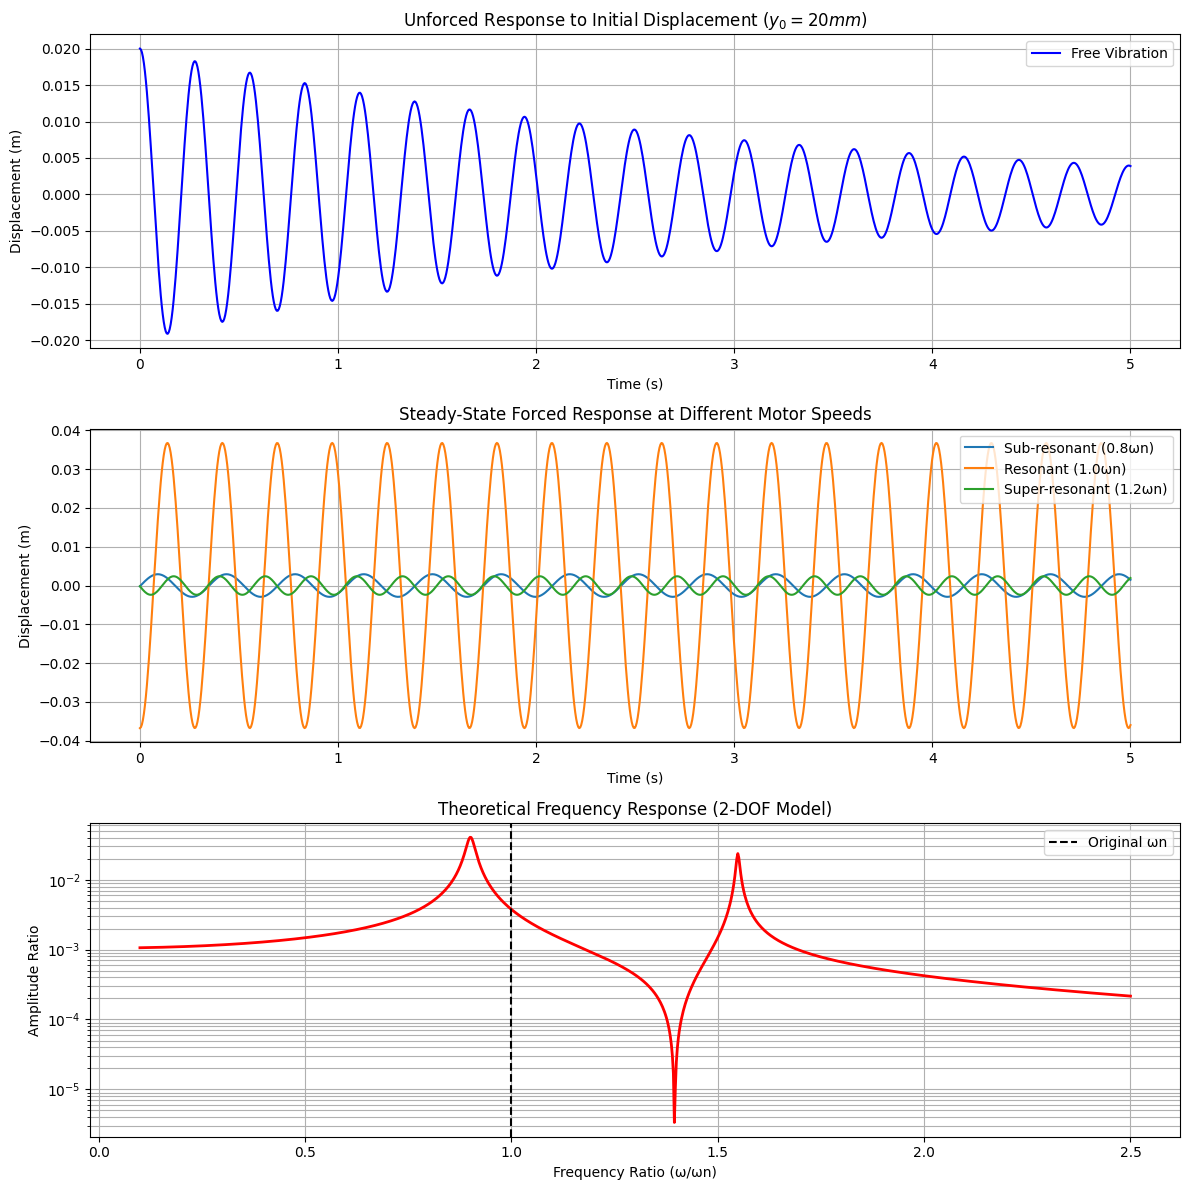

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

m1 = 1.85      # Effective mass of beam + exciter (kg)
k_beam = 950   # Beam stiffness (N/m)
c = 1.2        # Damping coefficient (N.s/m)
m2 = 0.25      # Absorber mass (kg)
k_abs = 250    # Absorber stiffness (N/m)

wn = np.sqrt(k_beam / m1)  # Natural frequency (rad/s)
zeta = c / (2 * np.sqrt(k_beam * m1)) # Damping ratio
wd = wn * np.sqrt(1 - zeta**2)        # Damped natural frequency

#---------------------------------------------------------------------------------------------------------

# 1. UNFORCED RESPONSE (Free Vibration)
t = np.linspace(0, 5, 1000)
y0 = 0.02  # Initial displacement (20mm)
v0 = 0     # Initial velocity
free_response = np.exp(-zeta * wn * t) * (y0 * np.cos(wd * t) + ((v0 + zeta * wn * y0) / wd) * np.sin(wd * t))

# 2. FORCED RESPONSE (3 Motor Speeds)
def forced_response(t, omega_motor, F0=1.0):
    # Steady state amplitude calculation
    mag = F0 / np.sqrt((k_beam - m1 * omega_motor**2)**2 + (c * omega_motor)**2)
    phase = np.arctan2(c * omega_motor, (k_beam - m1 * omega_motor**2))
    return mag * np.sin(omega_motor * t - phase)

speeds = [0.8 * wn, 1.0 * wn, 1.2 * wn] # Sub-resonant, Resonant, Super-resonant
labels = ['Sub-resonant (0.8ωn)', 'Resonant (1.0ωn)', 'Super-resonant (1.2ωn)']

# 3. 2-DOF FREQUENCY RESPONSE (Main Beam with Absorber)
w_range = np.linspace(0.1 * wn, 2.5 * wn, 1000)
def get_2dof_amplitude(w):
    # Impedance-based derivation for main beam amplitude Y1
    Z1 = (k_beam + k_abs - m1 * w**2 + 1j * c * w)
    Z2 = (k_abs - m2 * w**2)
    Z12 = -k_abs
    return np.abs(Z2 / (Z1 * Z2 - Z12**2))

amp_2dof = [get_2dof_amplitude(w) for w in w_range]

# --- PLOTTING ---
plt.figure(figsize=(12, 12))

# Plot 1: Unforced Response
plt.subplot(3, 1, 1)
plt.plot(t, free_response, 'b', label='Free Vibration')
plt.title('Unforced Response to Initial Displacement ($y_0=20mm$)')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.grid(True)
plt.legend()

# Plot 2: Forced Response
plt.subplot(3, 1, 2)
for s, l in zip(speeds, labels):
    plt.plot(t, forced_response(t, s), label=l)
plt.title('Steady-State Forced Response at Different Motor Speeds')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True)

# Plot 3: 2-DOF Frequency Response
plt.subplot(3, 1, 3)
plt.plot(w_range / wn, amp_2dof, 'r', linewidth=2)
plt.axvline(x=1.0, color='k', linestyle='--', label='Original ωn')
plt.title('Theoretical Frequency Response (2-DOF Model)')
plt.xlabel('Frequency Ratio (ω/ωn)')
plt.ylabel('Amplitude Ratio')
plt.yscale('log')
plt.grid(True, which="both", ls="-")
plt.legend()

plt.tight_layout()
plt.show()

#Activity 04

RESULTS FROM HALF-POWER METHOD:

Mode   | Peak Freq (Hz)  | Max Amp    | Calculated Zeta (ζ) 
-----------------------------------------------------------------
1      | 12.0060         | 7.6133     | 0.24542             
2      | 12.5063         | 13.1853    | 0.06380             
3      | 13.0215         | 34.7895    | 0.01556             
4      | 13.5818         | 12.4835    | 0.06262             
5      | 14.1071         | 7.5678     | 0.20922             
6      | 16.0330         | 8.7507     | 0.05616             
7      | 16.5333         | 11.7317    | 0.02874             
8      | 17.0385         | 7.3456     | 0.17675             


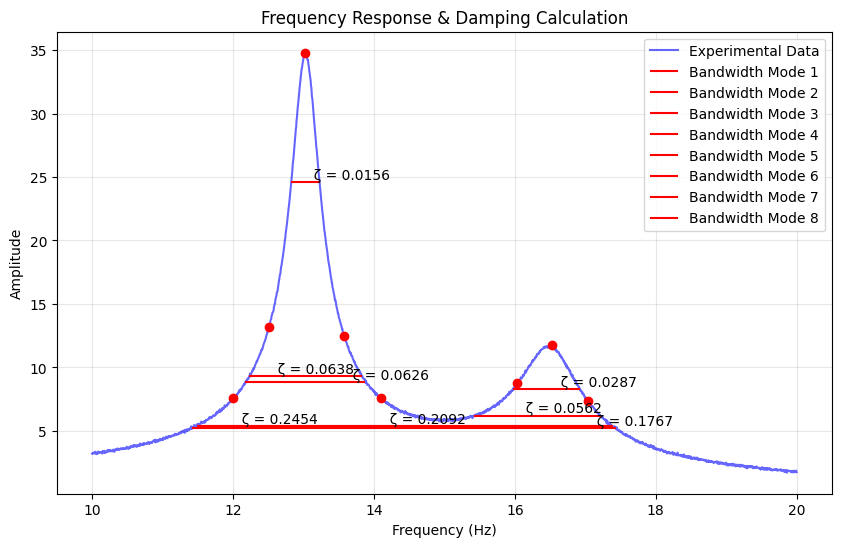

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ==========================================
# 1. INPUT DATA (Replace this section with your real data)
# ==========================================
# We simulate data here so the code runs immediately.
# In a real experiment, you would load your CSV or enter arrays manually.

# Frequency range: 10 Hz to 20 Hz
freq_data = np.linspace(10, 20, 2000)

# Simulate a 2-DOF response (Theoretical Transfer Function)
# Peak 1 at 13.0 Hz, Peak 2 at 16.5 Hz
w = 2 * np.pi * freq_data
w1 = 2 * np.pi * 13.03
w2 = 2 * np.pi * 16.50
z1_real = 0.015  # The "true" damping we want to find
z2_real = 0.025

# Theoretical Amplitude Curve
resp1 = 1 / np.sqrt((1 - (w/w1)**2)**2 + (2*z1_real*w/w1)**2)
resp2 = 0.5 / np.sqrt((1 - (w/w2)**2)**2 + (2*z2_real*w/w2)**2)
amp_data = resp1 + resp2 + np.random.normal(0, 0.05, len(freq_data)) # Adding some noise

# ==========================================
# 2. CALCULATION: Half-Power Bandwidth Method
# ==========================================

def calculate_damping_ratios(freqs, amps):
    print(f"{'Mode':<6} | {'Peak Freq (Hz)':<15} | {'Max Amp':<10} | {'Calculated Zeta (ζ)':<20}")
    print("-" * 65)

    # 1. Find the Peaks
    # 'distance' ensures we don't pick multiple points on the same peak
    # 'height' ignores small noise
    peaks, _ = find_peaks(amps, height=np.max(amps)*0.2, distance=100)

    results = []

    for i, p_idx in enumerate(peaks):
        f_n = freqs[p_idx]       # Natural Frequency
        A_max = amps[p_idx]      # Maximum Amplitude at resonance
        A_half = A_max / np.sqrt(2) # Target amplitude (0.707 * max)

        # 2. Find Half-Power Points (f1 and f2)
        # Scan left from peak to find f1
        idx_lower = np.where(amps[:p_idx] < A_half)[0]
        if len(idx_lower) > 0:
            f1 = freqs[idx_lower[-1]]
        else:
            f1 = freqs[0]

        # Scan right from peak to find f2
        idx_upper = np.where(amps[p_idx:] < A_half)[0]
        if len(idx_upper) > 0:
            f2 = freqs[p_idx + idx_upper[0]]
        else:
            f2 = freqs[-1]

        # 3. Calculate Zeta
        bandwidth = f2 - f1
        zeta = bandwidth / (2 * f_n)

        results.append((f_n, zeta, f1, f2, A_half))
        print(f"{i+1:<6} | {f_n:<15.4f} | {A_max:<10.4f} | {zeta:<20.5f}")

    return results

# ==========================================
# 3. EXECUTE & PLOT RESULTS
# ==========================================
print("RESULTS FROM HALF-POWER METHOD:\n")
modes = calculate_damping_ratios(freq_data, amp_data)

# Plotting for Verification
plt.figure(figsize=(10, 6))
plt.plot(freq_data, amp_data, 'b-', alpha=0.6, label='Experimental Data')
plt.title('Frequency Response & Damping Calculation')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')

for i, (fn, zeta, f1, f2, A_half) in enumerate(modes):
    # Plot the half-power bandwidth line
    plt.hlines(A_half, f1, f2, colors='r', linestyles='solid', label=f'Bandwidth Mode {i+1}')
    plt.plot(fn, np.max(amp_data[np.where(freq_data==fn)]), 'ro') # Mark peak
    plt.text(fn, A_half, f"  ζ = {zeta:.4f}", verticalalignment='bottom')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Activity 05

DESIGN TARGET: Primary System Resonance is at 10.97 Hz
DESIGN REQUIREMENT: Absorber Stiffness k_a must be 950.0 N/m
   (With m_a = 0.2 kg)


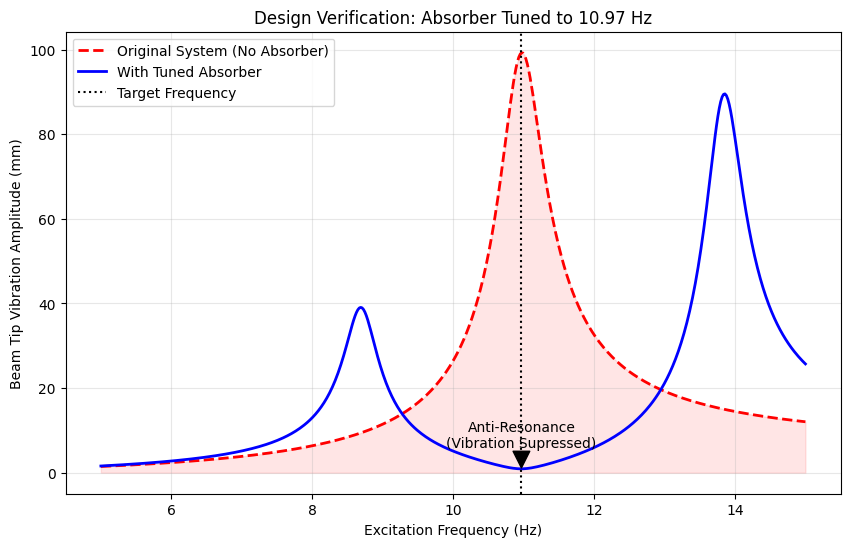

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINE PRIMARY SYSTEM (Rigid Beam)
# ==========================================
# Parameters based on TM1016V Manual specs
m_beam = 1.65   # kg
L_beam = 0.8    # m
l_s = 0.8       # Spring distance (m)
l_e = 0.4       # Motor distance (m)
k_s = 3800.0    # Main spring stiffness (N/m)
m_motor = 1.0   # Motor assembly mass (kg)

# Equivalent Stiffness (Rotational)
K_theta = k_s * (l_s**2)

# Equivalent Inertia (About Pivot)
# Beam (rod at end) + Motor (point mass)
I_A = (1/3)*m_beam*(L_beam**2) + m_motor*(l_e**2)

# Calculate Target Resonance Frequency
omega_n = np.sqrt(K_theta / I_A)
f_target = omega_n / (2 * np.pi)

print(f"DESIGN TARGET: Primary System Resonance is at {f_target:.2f} Hz")

# ==========================================
# 2. DESIGN THE ABSORBER (TUNING)
# ==========================================
# We choose a mass ratio (mu) typical for lab equipment (approx 5-10% of effective mass)
m_absorber = 0.2  # kg (Selected mass)
l_a = 0.75        # Position of absorber on beam (m)

# Tuning Condition: omega_absorber = omega_primary
# k_eff_absorber / m_absorber = K_theta / I_A
# Note: The absorber acts at a distance l_a.
# For a simplified linear approximation at the attachment point:
k_absorber_required = m_absorber * (omega_n**2)

print(f"DESIGN REQUIREMENT: Absorber Stiffness k_a must be {k_absorber_required:.1f} N/m")
print(f"   (With m_a = {m_absorber} kg)")


# ==========================================
# 3. SIMULATION: Frequency Response Function
# ==========================================
freqs = np.linspace(5, 15, 500)
response_no_abs = []
response_with_abs = []

# System Matrices Setup
M = np.array([[I_A, 0], [0, m_absorber]])
K = np.array([[K_theta + k_absorber_required*(l_a**2), -k_absorber_required*l_a],
              [-k_absorber_required*l_a,               k_absorber_required]])

# Small Damping for realism
C = np.array([[2.0, 0], [0, 0.5]])
m_unbal = 0.009 # kg.m

for f in freqs:
    w = 2 * np.pi * f

    # --- Case A: No Absorber (1-DOF) ---
    # Equation: (-w^2 I_A + jwC + K_theta) * Theta = F
    Z_1dof = K_theta - (w**2)*I_A + 1j*w*2.0
    F_mag = m_unbal * (w**2) # Force grows with speed
    Theta_1dof = (F_mag * l_e) / Z_1dof
    response_no_abs.append(abs(Theta_1dof) * l_s * 1000) # mm at tip

    # --- Case B: With Tuned Absorber (2-DOF) ---
    # Dynamic Stiffness Matrix Z = K - w^2M + jwC
    Z_2dof = K - (w**2)*M + 1j*w*C
    F_vec = np.array([F_mag * l_e, 0])

    Q = np.linalg.solve(Z_2dof, F_vec)
    response_with_abs.append(abs(Q[0]) * l_s * 1000) # mm at tip

# ==========================================
# 4. PLOTTING THE JUSTIFICATION
# ==========================================
plt.figure(figsize=(10, 6))

# Plot 1: Uncontrolled
plt.plot(freqs, response_no_abs, 'r--', linewidth=2, label='Original System (No Absorber)')
plt.fill_between(freqs, response_no_abs, color='red', alpha=0.1)

# Plot 2: Controlled
plt.plot(freqs, response_with_abs, 'b-', linewidth=2, label='With Tuned Absorber')

plt.title(f'Design Verification: Absorber Tuned to {f_target:.2f} Hz')
plt.xlabel('Excitation Frequency (Hz)')
plt.ylabel('Beam Tip Vibration Amplitude (mm)')
plt.axvline(f_target, color='k', linestyle=':', label='Target Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# Annotate the "Notch"
notch_amp = np.min(response_with_abs[np.abs(freqs - f_target).argmin()-10 : np.abs(freqs - f_target).argmin()+10])
plt.annotate('Anti-Resonance\n(Vibration Supressed)', xy=(f_target, notch_amp), xytext=(f_target, notch_amp+5),
             arrowprops=dict(facecolor='black', shrink=0.05), ha='center')

plt.show()